# Q1. Missing Data Identification

Scenario:
The hospital suspects incomplete patient records.
Task:
Identify missing values in each column
Calculate percentage of missing data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'C:\Users\soumy\Downloads\healthcare_data_cleaning_dataset.csv')

# Missing values count
missing_count = df.isnull().sum()

# Percentage
missing_percent = (df.isnull().sum() / len(df)) * 100

# Combine results
missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Percentage": missing_percent
})

print(missing_df)

                    Missing Count  Percentage
Patient_ID                      0    0.000000
Age                           600   11.764706
Gender                          0    0.000000
City                            0    0.000000
Diagnosis                       0    0.000000
Hospital_Visits                 0    0.000000
Treatment_Cost                593   11.627451
Insurance_Coverage              0    0.000000
Admission_Date                  0    0.000000


# Q2. Handling Missing Age

Scenario:
Age is critical for medical analysis, but some values are missing.
Task:
Replace missing Age values with an appropriate method
Justify your choice (mean/median)

In [2]:
# Using median (robust to outliers)
median_age = df['Age'].median()

df['Age'].fillna(median_age, inplace=True)

print("Missing Age values handled using median.")

Missing Age values handled using median.


C:\Users\soumy\AppData\Local\Temp\ipykernel_13628\255204493.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_age, inplace=True)


# Q3. Handling Missing Treatment Cost

Handle missing Treatment_Cost values and choose the correct imputation method.

In [3]:
# Treatment cost is skewed → use median
median_cost = df['Treatment_Cost'].median()

df['Treatment_Cost'].fillna(median_cost, inplace=True)

print("Missing Treatment_Cost handled using median.")

Missing Treatment_Cost handled using median.


C:\Users\soumy\AppData\Local\Temp\ipykernel_13628\503569906.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Treatment_Cost'].fillna(median_cost, inplace=True)


# Q4. Duplicate Patient Records

Identify duplicate rows, remove them, and compare dataset size before and after.

In [4]:
# Check duplicates
duplicate_rows = df.duplicated().sum()
print("Duplicate rows:", duplicate_rows)

# Remove duplicates
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 99
Shape after removing duplicates: (5001, 9)


# Q5. Invalid Age Values (Data Quality Check)

Detect unrealistic age values (e.g., <0 or >100) and handle them.

In [5]:
# Detect invalid ages
invalid_age = df[(df['Age'] < 0) | (df['Age'] > 100)]
print("Invalid age records:\n", invalid_age)

# Replace invalid values with median
df.loc[(df['Age'] < 0) | (df['Age'] > 100), 'Age'] = df['Age'].median()

print("Invalid ages corrected.")

Invalid age records:
 Empty DataFrame
Columns: [Patient_ID, Age, Gender, City, Diagnosis, Hospital_Visits, Treatment_Cost, Insurance_Coverage, Admission_Date]
Index: []
Invalid ages corrected.


# Q6. Outlier Detection (Treatment Cost)

Detect outliers using the IQR method and display the number of outliers.

In [6]:
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Treatment_Cost'] < lower_bound) | 
              (df['Treatment_Cost'] > upper_bound)]

print("Number of outliers:", outliers.shape[0])

Number of outliers: 50


# Q7. Outlier Treatment

Apply capping (Winsorization) on Treatment_Cost using 5th and 95th percentile.

In [7]:
lower_cap = df['Treatment_Cost'].quantile(0.05)
upper_cap = df['Treatment_Cost'].quantile(0.95)

df['Treatment_Cost'] = np.where(df['Treatment_Cost'] < lower_cap, lower_cap, df['Treatment_Cost'])
df['Treatment_Cost'] = np.where(df['Treatment_Cost'] > upper_cap, upper_cap, df['Treatment_Cost'])

print("Outliers capped using Winsorization.")

Outliers capped using Winsorization.


# Q8. Transformation

Apply log transformation to Treatment_Cost and compare distributions.

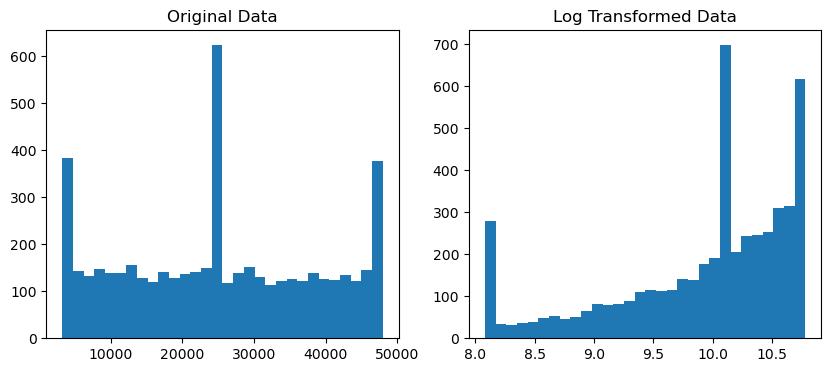

In [8]:
import matplotlib.pyplot as plt

# Log transformation
df['Log_Treatment_Cost'] = np.log1p(df['Treatment_Cost'])

# Plot comparison
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df['Treatment_Cost'], bins=30)
plt.title("Original Data")

plt.subplot(1,2,2)
plt.hist(df['Log_Treatment_Cost'], bins=30)
plt.title("Log Transformed Data")

plt.show()

# Q9. Time-Based Missing Handling

Sort data by Admission_Date and apply forward/backward fill.

In [9]:
# Convert to datetime
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

# Sort
df = df.sort_values(by='Admission_Date')

# Forward fill
df.fillna(method='ffill', inplace=True)

print("Missing values handled using forward fill.")

Missing values handled using forward fill.


C:\Users\soumy\AppData\Local\Temp\ipykernel_13628\3632219063.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
